In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import stim
import pymatching

In [3]:
def encode_repetition_code(logical_state, wires):
    if logical_state==1:
        qml.PauliX(wires=0)
    for i in range(1, len(wires)):
        qml.CNOT(wires=[wires[0], wires[i]])

In [4]:
def apply_bit_flip(wires, p):
    for w in wires:
        if np.random.random() < p:
            qml.PauliX(wires=w)

In [14]:
def measure_syndrome(wires):
    syndrome = []
    for i in range(1, len(wires)):
        syndrome.append(qml.expval(qml.Z(wires=i) @ qml.Z(wires=i+1)))
    return syndrome

def decode_majority_vote(measurements):
    if measurements.count(1) > measurements.count(-1):
        return 0
    else:
        return 1

Simulating for distance d=3...
Simulating for distance d=5...
Simulating for distance d=7...


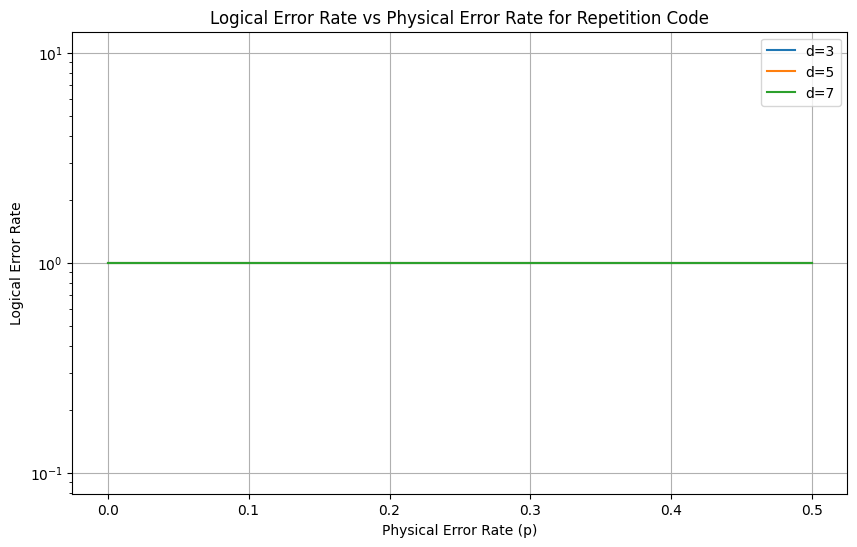

In [15]:
def simulate_repetition_code(d, p_err, shots = 10240):
    dev = qml.device('default.qubit', wires = d)

    logical_errors = 0
    for _ in range(shots):
        encode_repetition_code(0, wires=range(d))
        apply_bit_flip(wires=range(d), p=p_err)
        syndrome = measure_syndrome(wires=range(d))
        decoded_state = decode_majority_vote(syndrome)
        if decoded_state != 0:
            logical_errors += 1
    return logical_errors / shots

distances = [3, 5, 7]
error_rates = np.linspace(0, 0.5, 11)
results = []
for d in distances:
    print(f'Simulating for distance d={d}...')
    error_rates_d = []
    for p in error_rates:
        error_rate = simulate_repetition_code(d, p)
        error_rates_d.append(error_rate)
    results.append(error_rates_d)

plt.figure(figsize=(10, 6))
for i, d in enumerate(distances):
    plt.plot(error_rates, results[i], label=f'd={d}')
plt.yscale('log')
plt.xlabel('Physical Error Rate (p)')
plt.ylabel('Logical Error Rate')
plt.title('Logical Error Rate vs Physical Error Rate for Repetition Code')
plt.legend()
plt.grid()
plt.show()


In [16]:
circuit = stim.Circuit.generated(
    'surface_code:rotated_memory_z',
    distance = 3,
    rounds = 3,
    after_clifford_depolarization = 0.01
)

sampler = circuit.compile_detector_sampler()
detector_samples, observable_samples = sampler.sample(100000, separate_observables=True)

matcher = pymatching.Matching.from_detector_error_model(circuit.detector_error_model())

predictions = matcher.decode_batch(detector_samples)
logical_errors = np.sum(predictions != observable_samples)
print(f"Logical error rate: {logical_errors / len(detector_samples)}")

Logical error rate: 0.02288
